本プロジェクトでは、ECサイトのレビューから顧客の感情を分析し、
業務改善に活用できる情報を抽出することを目的とする。

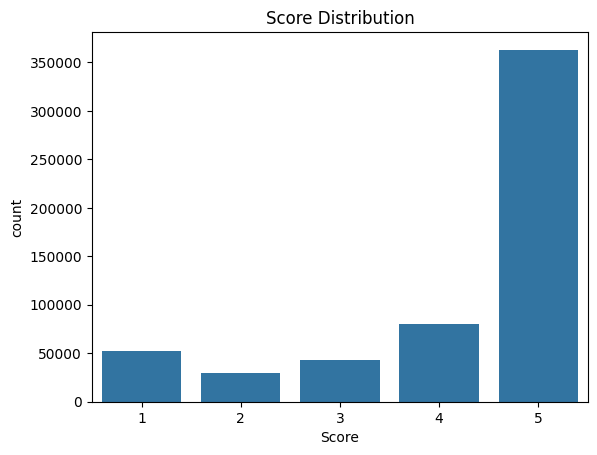

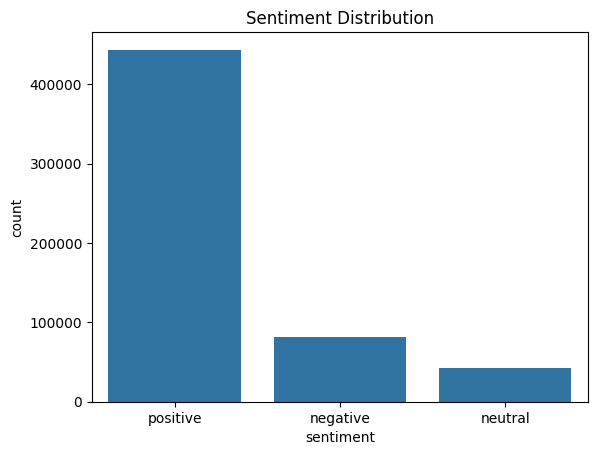

              precision    recall  f1-score   support

    negative       0.88      0.41      0.56       657
    positive       0.90      0.99      0.94      3343

    accuracy                           0.89      4000
   macro avg       0.89      0.70      0.75      4000
weighted avg       0.89      0.89      0.88      4000



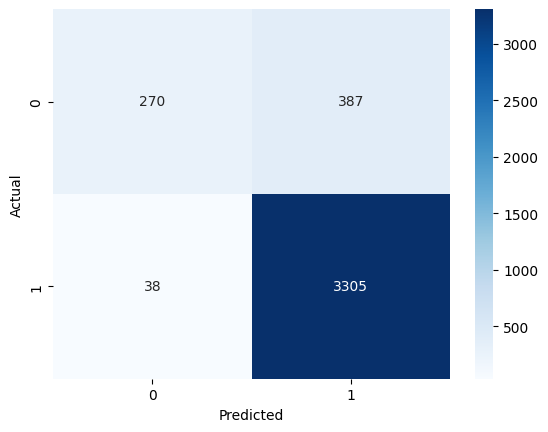

--- Top Negative Words ---
               word  importance
1262   disappointed   -4.537198
4935          worst   -4.520613
4160          stale   -3.892834
4455       terrible   -3.883200
266           awful   -3.773052
2133       horrible   -3.746568
2668          maybe   -3.683366
275             bad   -3.612165
2811          money   -3.547426
4819          waste   -3.405645
4680  unfortunately   -3.181070
1217            did   -3.155275
4411      tasteless   -2.809821
3649         return   -2.769586
4506          threw   -2.755814
4505        thought   -2.696986
1219          didnt   -2.580860
2132         hoping   -2.573025
3526       received   -2.553873
4934          worse   -2.548183

--- Top Positive Words ---
           word  importance
1929      great    7.098129
371        best    5.271525
1157  delicious    4.380543
2569       love    4.277400
3162    perfect    4.204711
2575      loves    4.161283
1494  excellent    3.987261
1587   favorite    3.727866
2902       nice    3.

In [12]:
# レビュー感情分析プロジェクト

import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# データの読み込み（CSVファイルからレビューデータをロード）
df = pd.read_csv(r"data_analysis_amazon\data\Reviews.csv") 

# データ理解（各スコアの出現回数を確認）
df["Score"].value_counts()

# スコア分布の可視化
sns.countplot(x="Score", data=df)
plt.title("Score Distribution")
plt.show()

# スコアに基づいて感情ラベル（positive/negative/neutral）を定義する関数
def label_sentiment(score):
    if score >= 4:
        return "positive"
    elif score <= 2:
        return "negative"
    else:
        return "neutral"

# 感情ラベルの適用
df["sentiment"] = df["Score"].apply(label_sentiment)

# データの偏りを把握する
df["sentiment"].value_counts()

# レビュースコア分布の可視化
sns.countplot(x="sentiment", data=df)
plt.title("Sentiment Distribution")
plt.show()

# 分析対象の絞り込み（中立的なレビューを除外し、計算コスト削減のため20,000件をサンプリング）
df = df[df["sentiment"] != "neutral"] 
df = df.sample(20000, random_state=42)

# テキストのクリーニング関数（前処理）
def clean_text(text):
    # 小文字化
    text = text.lower()
    
    # 記号・数字の削除
    text = re.sub(r"[^a-z\s]", "", text)
    
    # ストップワード（分析に不要な一般的な単語）の除去
    words = text.split()
    words = [word for word in words if word not in ENGLISH_STOP_WORDS]
    
    return " ".join(words)

# クリーニング処理を実行
df["clean_text"] = df["Text"].apply(clean_text)

# TF-IDFによるテキストの数値化（単語の重要度に基づいたベクトル化）
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df["clean_text"])
y = df["sentiment"]

# データを訓練用（80%）とテスト用（20%）に分割
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ロジスティック回帰モデルの構築と学習
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# テストデータを用いた予測の実行
y_pred = model.predict(X_test)

# 精度の評価レポート（適合率、再現率、F1スコアなど）の表示
print(classification_report(y_test, y_pred)) 

# 混同行列（Confusion Matrix）の作成
cm = confusion_matrix(y_test, y_pred) 

# 混同行列のヒートマップ可視化
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual") 
plt.show()

# 学習したモデルの係数から、感情に寄与している単語を特定
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0] 

coef_df = pd.DataFrame({
    "word": feature_names,
    "importance": coefficients
})

# ネガティブな感情に強く影響している単語（係数が小さい順）
print("--- Top Negative Words ---")
print(coef_df.sort_values("importance").head(20))

# ポジティブな感情に強く影響している単語（係数が大きい順）
print("\n--- Top Positive Words ---")
print(coef_df.sort_values("importance", ascending=False).head(20))

## 考察

本分析では、レビューから感情分類を行い、
顧客の評価傾向を可視化した。

ネガティブレビューでは「bad」「worst」などの単語が多く、
品質や期待とのギャップに対する不満が見られた。

一方、ポジティブレビューでは「great」「delicious」などが多く、
商品の品質や満足度の高さが評価されていることがわかる。

これにより、企業はネガティブ要因を特定し、
商品改善や顧客満足度向上に活用できると考えられる。